# T-GCN — Standalone Convergence Diagnostic

Isolated from the full AgroVedha notebook to test T-GCN's behavior with an extended training budget. Original run: **RMSE=1.6773, R2=0.9745** (3 epochs). GCN's benchmark (best Track B model, well-converged) was RMSE=1.1938, R2=0.9870 — use that as your reference ceiling.

T-GCN trains sequentially (one timestep at a time, truncated BPTT in chunks) rather than batched like the static models — inherently slower per epoch, so extended training here means real wall-clock time, not just a config change.



## Setup — Load data, build graph, build windows (same as main notebook)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = "/kaggle/input/datasets/akshaymp08/bhopal-agritech-dataset-for-predictive-irrigation/Bhopal-AgriTech Hybrid IoT Dataset for Predictive Irrigation.csv"
df = pd.read_csv(DATA_PATH)
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)

target_col = "soil_moisture_next_1m"
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()
print(f"Train: {len(train_df):,} rows | Test: {len(test_df):,} rows")

Train: 33,352 rows | Test: 8,339 rows


In [2]:
def eval_metrics(y_true, y_pred):
    return (
        np.sqrt(mean_squared_error(y_true, y_pred)),
        mean_absolute_error(y_true, y_pred),
        r2_score(y_true, y_pred),
    )

graph_nodes = ["Soil_Moisture", "Temperature", "Humidity", "irrigation_status", "Hour_sin", "Hour_cos"]
n_nodes = len(graph_nodes)

corr_graph = df[graph_nodes].corr().values
np.fill_diagonal(corr_graph, 0)

edge_index_list, edge_weight_list = [], []
for i in range(n_nodes):
    for j in range(n_nodes):
        if i != j:
            edge_index_list.append([i, j])
            edge_weight_list.append(abs(corr_graph[i, j]))

edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
print(f"edge_index shape: {edge_index.shape}")

edge_index shape: torch.Size([2, 30])


In [3]:
WINDOW = 60

node_scalers = {}
train_scaled_g, test_scaled_g = {}, {}
for col in graph_nodes:
    sc = MinMaxScaler()
    train_scaled_g[col] = sc.fit_transform(train_df[[col]]).flatten()
    test_scaled_g[col] = sc.transform(test_df[[col]]).flatten()
    node_scalers[col] = sc

target_scaler_g = MinMaxScaler()
train_target_scaled_g = target_scaler_g.fit_transform(train_df[[target_col]]).flatten()
test_target_scaled_g = target_scaler_g.transform(test_df[[target_col]]).flatten()

def build_windows(scaled_dict, target_scaled, window):
    n = len(next(iter(scaled_dict.values())))
    X, y = [], []
    for t in range(n - window):
        snapshot = np.stack([scaled_dict[col][t:t + window] for col in graph_nodes])
        X.append(snapshot)
        y.append(target_scaled[t + window])
    return np.array(X), np.array(y)

X_train_g, y_train_g = build_windows(train_scaled_g, train_target_scaled_g, WINDOW)
X_test_g, y_test_g = build_windows(test_scaled_g, test_target_scaled_g, WINDOW)

y_true_g = target_scaler_g.inverse_transform(y_test_g.reshape(-1, 1)).flatten()
print(f"X_train_g: {X_train_g.shape}  X_test_g: {X_test_g.shape}")

X_train_g: (33292, 6, 60)  X_test_g: (8279, 6, 60)


In [4]:
import torch
TORCH_VERSION = torch.__version__.split("+")[0]
CUDA_VERSION = "cu" + torch.version.cuda.replace(".", "") if torch.cuda.is_available() else "cpu"
wheel_url = f"https://data.pyg.org/whl/torch-{TORCH_VERSION}+{CUDA_VERSION}.html"
print(f"Using wheel index: {wheel_url}")
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv -f {wheel_url} -q
!pip install torch_geometric torch_geometric_temporal -q

Using wheel index: https://data.pyg.org/whl/torch-2.10.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.4/682.4 kB 10.9 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.0 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.2/828.2 kB 37.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.9/306.9 kB 17.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 4.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mne 1.12.1 requires decorator>=5.1, but you have decorator 4.4.2 which is incompatible.


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

X_train_t = torch.tensor(X_train_g, dtype=torch.float32)
y_train_t = torch.tensor(y_train_g, dtype=torch.float32).unsqueeze(-1)
X_test_t = torch.tensor(X_test_g, dtype=torch.float32)

edge_index_dev = edge_index.to(device)
edge_weight_dev = edge_weight.to(device)

batch_size = 128
n_batches = len(X_train_t) // batch_size
loss_fn = nn.MSELoss()

Using device: cpu


In [6]:
train_seq = np.stack([train_scaled_g[col] for col in graph_nodes], axis=1)
test_seq = np.stack([test_scaled_g[col] for col in graph_nodes], axis=1)
CHUNK = 60
n_chunks = (len(train_seq) - 1) // CHUNK
print(f"n_chunks per epoch: {n_chunks}")

n_chunks per epoch: 555


## T-GCN Model

In [7]:
from torch_geometric_temporal.nn.recurrent import TGCN

class TGCNForecaster(nn.Module):
    def __init__(self, in_channels=1, hidden_channels=32):
        super().__init__()
        self.tgcn = TGCN(in_channels, hidden_channels)
        self.readout = nn.Linear(hidden_channels * n_nodes, 1)

    def forward(self, x, edge_index, edge_weight, h=None):
        h = self.tgcn(x, edge_index, edge_weight, h)
        return self.readout(h.flatten()), h

print("T-GCN model class defined.")

T-GCN model class defined.


## Extended Training — watch the loss curve

`N_EPOCHS` here is more expensive than the batched models given sequential processing — 8 is a starting point (~2.5x the original 3-epoch run). Raise cautiously and watch wall-clock time.

In [8]:
N_EPOCHS = 30

model = TGCNForecaster().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
train_losses = []

model.train()
for epoch in range(N_EPOCHS):
    h = None
    total_loss = 0.0
    for c in range(n_chunks):
        optimizer.zero_grad()
        chunk_loss = 0.0
        h_local = h.detach() if h is not None else None
        for t in range(c*CHUNK, (c+1)*CHUNK):
            x_t = torch.tensor(train_seq[t], dtype=torch.float32).unsqueeze(-1).to(device)
            y_t = torch.tensor([train_target_scaled_g[t]], dtype=torch.float32).to(device)
            pred, h_local = model(x_t, edge_index_dev, edge_weight_dev, h_local)
            chunk_loss = chunk_loss + loss_fn(pred, y_t)
        chunk_loss = chunk_loss / CHUNK
        chunk_loss.backward()
        optimizer.step()
        h = h_local.detach()
        total_loss += chunk_loss.item()
    avg_loss = total_loss / n_chunks
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{N_EPOCHS}: avg chunk loss={avg_loss:.6f}")

Epoch 1/30: avg chunk loss=0.024801
Epoch 2/30: avg chunk loss=0.002214
Epoch 3/30: avg chunk loss=0.004859
Epoch 5/30: avg chunk loss=0.005060
Epoch 6/30: avg chunk loss=0.000431
Epoch 7/30: avg chunk loss=0.002748
Epoch 8/30: avg chunk loss=0.000641
Epoch 9/30: avg chunk loss=0.005519
Epoch 10/30: avg chunk loss=0.000708
Epoch 11/30: avg chunk loss=0.000417
Epoch 12/30: avg chunk loss=0.003815
Epoch 13/30: avg chunk loss=0.000374
Epoch 14/30: avg chunk loss=0.000415
Epoch 15/30: avg chunk loss=0.004469
Epoch 16/30: avg chunk loss=0.000349
Epoch 17/30: avg chunk loss=0.000361
Epoch 18/30: avg chunk loss=0.001181
Epoch 19/30: avg chunk loss=0.000481
Epoch 20/30: avg chunk loss=0.003137
Epoch 21/30: avg chunk loss=0.000378
Epoch 22/30: avg chunk loss=0.000545
Epoch 23/30: avg chunk loss=0.001112
Epoch 24/30: avg chunk loss=0.000409
Epoch 25/30: avg chunk loss=0.001599
Epoch 26/30: avg chunk loss=0.000482
Epoch 27/30: avg chunk loss=0.000449
Epoch 28/30: avg chunk loss=0.001119
Epoch 29/

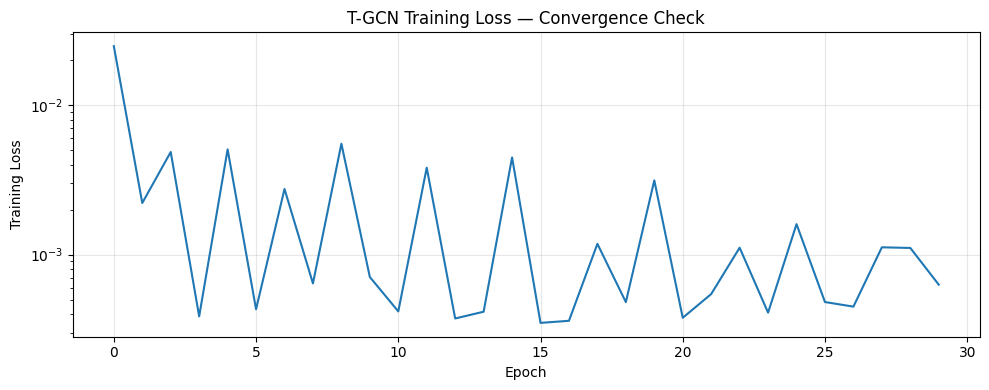


First 5 epochs avg loss: 0.007464
Last 5 epochs avg loss:  0.000757
Loss still decreasing in final 5 epochs: False


In [9]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("T-GCN Training Loss — Convergence Check")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFirst 5 epochs avg loss: {np.mean(train_losses[:5]):.6f}")
print(f"Last 5 epochs avg loss:  {np.mean(train_losses[-5:]):.6f}")
print(f"Loss still decreasing in final 5 epochs: {train_losses[-1] < train_losses[-5]}")

## Evaluation

In [10]:
model.eval()
preds = []
h = None
with torch.no_grad():
    for t in range(len(test_seq)):
        x_t = torch.tensor(test_seq[t], dtype=torch.float32).unsqueeze(-1).to(device)
        pred, h = model(x_t, edge_index_dev, edge_weight_dev, h)
        preds.append(pred.cpu().item())

pred_scaled = np.array(preds[:-1])
y_true_scaled = test_target_scaled_g[1:]
pred = target_scaler_g.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
y_true = target_scaler_g.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()

rmse, mae, r2 = eval_metrics(y_true, pred)
print(f"T-GCN ({N_EPOCHS} epochs) — RMSE: {rmse:.4f}  MAE: {mae:.4f}  R2: {r2:.4f}")
print()
print("For reference:")
print(f"  Original run (3 epochs):  RMSE=1.6773  R2=0.9745")
print(f"  GCN benchmark:            RMSE=1.1938  R2=0.9870")

T-GCN (30 epochs) — RMSE: 1.8987  MAE: 1.3665  R2: 0.9673

For reference:
  Original run (3 epochs):  RMSE=1.6773  R2=0.9745
  GCN benchmark:            RMSE=1.1938  R2=0.9870


## Interpreting the result

T-GCN already performed reasonably well (R²=0.975) despite its slower, sequential training — among the better temporal architectures in the original run. If it improves further here, that's genuine headroom recovered from a limited training budget. If it plateaus near the same number, the original 3-epoch result was already a fair representation of this architecture's capability on this task.